# Sentiment Analysis using Transformers Pipeline

# Developed by DEEPAK.M AI Generalist IPEC Solution Private Limited Bangalore.


In [1]:
import sys
!{sys.executable} -m pip install vaderSentiment

Defaulting to user installation because normal site-packages is not writeable


# VADER
VADER (Valence Aware Dictionary and sEntiment Reasoner) is a lexicon and rule-based sentiment analysis tool

**Key Features**
- Social Media Optimized: Effectively handles slang, emojis, capitalization (e.g., "GREAT"), and intensive punctuation (e.g., "!!!").
- Lexicon-Based: Uses a dictionary of words mapped to "valence scores" (positivity or negativity) based on human ratings.
- No Training Required: Unlike machine learning models, it works "out of the box" without needing a training dataset.
- Open Source: Distributed under the MIT License.

**Understanding the Scores**
VADER returns a dictionary with four main values: 
pos, neu, neg: The proportion of the text that is positive, neutral, or negative (summing to 1).
compound: The most important metric—a single normalized score from -1 (extremely negative) to +1 (extremely positive). 

Common Thresholds for Compound Score:
- 1.Positive: > 0.05
- 2.Neutral:  > -0.05 and <0.05
- 3.Negative: < 0.05

# TextBlob
TextBlob is an open-source Python library designed for simplified textual data processing and common Natural Language Processing (NLP) tasks. It is built on top of the NLTK (Natural Language Toolkit) and the Pattern library, offering a more intuitive, "Pythonic" API for beginners and quick prototyping. 
 
**Core Features**
- Sentiment Analysis: Provides a simple way to analyze text sentiment, returning polarity (ranging from -1.0 for negative to 1.0 for positive) and subjectivity (0.0 for objective to 1.0 for subjective).
- Tokenization: Breaks text into individual words or sentences.
- Part-of-Speech (POS) Tagging: Automatically identifies the grammatical role of each word (e.g., noun, verb, adjective).
- Noun Phrase Extraction: Extracts significant noun phrases to summarize key concepts.
- Word Inflection & Lemmatization: Easily handles pluralization, singularization, and finding root words (lemmas).
- Spelling Correction: Features a built-in method to suggest and apply spelling corrections.
- Translation & Language Detection: Powered by the Google Translate API, allowing for quick cross-language processing.
- Integration: Includes WordNet integration for finding definitions and synonyms.

# Transformer
The Hugging Face Transformers library is an open-source Python library that provides a unified interface for downloading, training, and deploying state-of-the-art pre-trained models across various modalities. 

**Key Features**
- Multi-Framework Support: Fully compatible with PyTorch, TensorFlow 2.0, and JAX/Flax, allowing seamless model exchange between frameworks.
- Task Modalities: Supports a wide range of fields including:
- NLP: Text classification, translation, summarization, and question answering.
- Computer Vision: Image classification, object detection, and segmentation.
- Audio: Automatic speech recognition and text-to-speech.
- Multimodal: Visual question answering and document information extraction.
- Model Hub Integration: Provides access to thousands of pre-trained models such as BERT, GPT, T5, Llama, and Stable Diffusion
VADER vs. Transformers
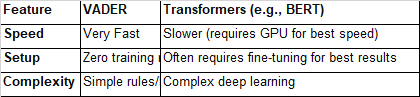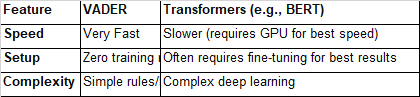

In [2]:
import warnings
warnings.filterwarnings('ignore')

In [3]:
from transformers import pipeline
classifier = pipeline('sentiment-analysis')
print(classifier('I love using the Transformers library!'))

No model was supplied, defaulted to distilbert/distilbert-base-uncased-finetuned-sst-2-english and revision 714eb0f.
Using a pipeline without specifying a model name and revision in production is not recommended.


config.json:   0%|          | 0.00/629 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

[{'label': 'POSITIVE', 'score': 0.9993904829025269}]


In [5]:
!pip install textblob

Defaulting to user installation because normal site-packages is not writeable
   ---------------------------------------- 0.0/625.0 kB ? eta -:--:--
   ---------------- ----------------------- 262.1/625.0 kB ? eta -:--:--
   ---------------------------------------- 625.0/625.0 kB 4.2 MB/s  0:00:00


In [6]:
"""
Sentiment Analysis using NLP — Python
Approaches:
  1. VADER       - Rule-based, fast, lexicon-driven (great for social media text)
  2. TextBlob    - Polarity + subjectivity scoring
  3. Transformers - Deep learning via HuggingFace (most accurate)
"""

# ── pip install vaderSentiment textblob transformers torch ──


# ─────────────────────────────────────────────
# 1. VADER — Valence Aware Dictionary and sEntiment Reasoner
# ─────────────────────────────────────────────
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

def vader_sentiment(text: str) -> dict:
    """
    Returns compound score + label.
    compound ∈ [-1, 1]:
        >= 0.05  → Positive
        <= -0.05 → Negative
        else     → Neutral
    """
    analyzer = SentimentIntensityAnalyzer()
    scores = analyzer.polarity_scores(text)
    compound = scores["compound"]

    if compound >= 0.05:
        label = "Positive"
    elif compound <= -0.05:
        label = "Negative"
    else:
        label = "Neutral"

    return {
        "text": text,
        "label": label,
        "compound": round(compound, 4),
        "positive": round(scores["pos"], 4),
        "negative": round(scores["neg"], 4),
        "neutral": round(scores["neu"], 4),
    }


# ─────────────────────────────────────────────
# 2. TextBlob — Polarity & Subjectivity
# ─────────────────────────────────────────────
from textblob import TextBlob

def textblob_sentiment(text: str) -> dict:
    """
    polarity    ∈ [-1.0, 1.0]  — negative → positive
    subjectivity∈ [0.0,  1.0]  — objective → subjective
    """
    blob = TextBlob(text)
    polarity = blob.sentiment.polarity
    subjectivity = blob.sentiment.subjectivity

    if polarity > 0.05:
        label = "Positive"
    elif polarity < -0.05:
        label = "Negative"
    else:
        label = "Neutral"

    return {
        "text": text,
        "label": label,
        "polarity": round(polarity, 4),
        "subjectivity": round(subjectivity, 4),
    }


# ─────────────────────────────────────────────
# 3. HuggingFace Transformers — Deep Learning
# ─────────────────────────────────────────────
from transformers import pipeline

def transformer_sentiment(texts: list[str], model: str = "distilbert-base-uncased-finetuned-sst-2-english") -> list[dict]:
    """
    Uses DistilBERT fine-tuned on SST-2 (Stanford Sentiment Treebank).
    Labels: POSITIVE / NEGATIVE (score = confidence).
    For 3-class (pos/neg/neutral), swap model to:
        'cardiffnlp/twitter-roberta-base-sentiment-latest'
    """
    classifier = pipeline("sentiment-analysis", model=model, truncation=True)
    raw_results = classifier(texts)

    results = []
    for text, res in zip(texts, raw_results):
        label = res["label"].capitalize()
        results.append({
            "text": text,
            "label": label,
            "confidence": round(res["score"], 4),
        })
    return results


# ─────────────────────────────────────────────
# 4. Batch Analyser — runs all three models
# ─────────────────────────────────────────────
def analyse_batch(texts: list[str]) -> list[dict]:
    """
    Runs VADER, TextBlob, and Transformer on each text.
    Returns a combined report per text.
    """
    transformer_results = transformer_sentiment(texts)

    combined = []
    for i, text in enumerate(texts):
        vader = vader_sentiment(text)
        blob  = textblob_sentiment(text)
        trans = transformer_results[i]

        combined.append({
            "text": text,
            "vader":       {"label": vader["label"],   "compound": vader["compound"]},
            "textblob":    {"label": blob["label"],    "polarity": blob["polarity"]},
            "transformer": {"label": trans["label"], "confidence": trans["confidence"]},
        })
    return combined


# ─────────────────────────────────────────────
# 5. Pretty-print utility
# ─────────────────────────────────────────────
def print_report(results: list[dict]) -> None:
    icons = {"Positive": "✅", "Negative": "❌", "Neutral": "➖"}

    for r in results:
        print(f"\n{'─'*60}")
        print(f"Text      : {r['text'][:80]}")
        print(f"VADER     : {icons.get(r['vader']['label'], '')} {r['vader']['label']:<10}  compound={r['vader']['compound']}")
        print(f"TextBlob  : {icons.get(r['textblob']['label'], '')} {r['textblob']['label']:<10}  polarity={r['textblob']['polarity']}")
        print(f"Transformer: {icons.get(r['transformer']['label'], '')} {r['transformer']['label']:<10}  confidence={r['transformer']['confidence']}")
    print(f"\n{'─'*60}\n")


# ─────────────────────────────────────────────
# 6. Demo
# ─────────────────────────────────────────────
if __name__ == "__main__":
    sample_texts = [
        "This product is absolutely amazing! I love it so much.",
        "Worst experience ever. Totally disappointed and will never buy again.",
        "The package arrived on time. It is okay, nothing special.",
        "I'm not sure how I feel about this — it's neither great nor terrible.",
        "The customer support was fantastic, but the product quality is really poor.",
    ]

    print("\n" + "="*60)
    print("     SENTIMENT ANALYSIS — NLP COMPARISON REPORT")
    print("="*60)

    # Individual models
    print("\n[VADER Results]")
    for text in sample_texts:
        r = vader_sentiment(text)
        print(f"  {r['label']:<10} (compound={r['compound']}) → {text[:60]}...")

    print("\n[TextBlob Results]")
    for text in sample_texts:
        r = textblob_sentiment(text)
        print(f"  {r['label']:<10} (polarity={r['polarity']}) → {text[:60]}...")

    print("\n[Transformer Results]")
    for r in transformer_sentiment(sample_texts):
        print(f"  {r['label']:<10} (conf={r['confidence']}) → {r['text'][:60]}...")

    # Combined batch report
    print("\n[Combined Batch Analysis]")
    results = analyse_batch(sample_texts)
    print_report(results)



     SENTIMENT ANALYSIS — NLP COMPARISON REPORT

[VADER Results]
  Positive   (compound=0.8705) → This product is absolutely amazing! I love it so much....
  Negative   (compound=-0.8173) → Worst experience ever. Totally disappointed and will never b...
  Negative   (compound=-0.092) → The package arrived on time. It is okay, nothing special....
  Negative   (compound=-0.7511) → I'm not sure how I feel about this — it's neither great nor ...
  Negative   (compound=-0.3484) → The customer support was fantastic, but the product quality ...

[TextBlob Results]
  Positive   (polarity=0.4833) → This product is absolutely amazing! I love it so much....
  Negative   (polarity=-0.875) → Worst experience ever. Totally disappointed and will never b...
  Positive   (polarity=0.4286) → The package arrived on time. It is okay, nothing special....
  Negative   (polarity=-0.15) → I'm not sure how I feel about this — it's neither great nor ...
  Neutral    (polarity=0.0) → The customer support was fa

config.json:   0%|          | 0.00/629 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

  Positive   (conf=0.9999) → This product is absolutely amazing! I love it so much....
  Negative   (conf=0.9997) → Worst experience ever. Totally disappointed and will never b...
  Negative   (conf=0.979) → The package arrived on time. It is okay, nothing special....
  Negative   (conf=0.9954) → I'm not sure how I feel about this — it's neither great nor ...
  Negative   (conf=0.9994) → The customer support was fantastic, but the product quality ...

[Combined Batch Analysis]


Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]


────────────────────────────────────────────────────────────
Text      : This product is absolutely amazing! I love it so much.
VADER     : ✅ Positive    compound=0.8705
TextBlob  : ✅ Positive    polarity=0.4833
Transformer: ✅ Positive    confidence=0.9999

────────────────────────────────────────────────────────────
Text      : Worst experience ever. Totally disappointed and will never buy again.
VADER     : ❌ Negative    compound=-0.8173
TextBlob  : ❌ Negative    polarity=-0.875
Transformer: ❌ Negative    confidence=0.9997

────────────────────────────────────────────────────────────
Text      : The package arrived on time. It is okay, nothing special.
VADER     : ❌ Negative    compound=-0.092
TextBlob  : ✅ Positive    polarity=0.4286
Transformer: ❌ Negative    confidence=0.979

────────────────────────────────────────────────────────────
Text      : I'm not sure how I feel about this — it's neither great nor terrible.
VADER     : ❌ Negative    compound=-0.7511
TextBlob  : ❌ Negativ